# Fase 2: Análisis Exploratorio de Datos (EDA) - Perfil Epidemiológico y Tendencias

Tras completar la fase de preprocesamiento y limpieza, contamos con un dataset consolidado de **85,043 registros** de mortalidad por cáncer de estómago en Colombia para el periodo **2008-2024**. 

Este análisis exploratorio tiene como objetivo desentrañar los patrones espaciales, temporales y demográficos de la enfermedad, sentando las bases estadísticas para el posterior desarrollo del modelo predictivo.

### Objetivos del EDA:
1.  **Análisis Temporal:** Identificar la evolución histórica de la mortalidad y detectar posibles cambios de tendencia (puntos de inflexión).
2.  **Análisis Demográfico:** Caracterizar el perfil de los fallecidos según sexo, edad, nivel educativo y régimen de salud.
3.  **Análisis Geográfico:** Visualizar la distribución territorial para identificar focos críticos de mortalidad a nivel departamental.
4.  **Calidad del Diagnóstico:** Evaluar la fiabilidad de la información reportada mediante el índice de calidad construido previamente.

In [1]:
# 1) Importar librerias y configurar entorno
import os
import gc
from pathlib import Path
import pyarrow
import fastparquet
from statsmodels.tsa.seasonal import seasonal_decompose
import missingno as msno
import numpy as np
import pandas as pd
import pyreadstat
import seaborn as sns
import matplotlib.pyplot as plt

RUTA_DATA = Path("Datos/mortalidad_estomago_colombia_2008_2024.parquet")

In [30]:
# Carga del dataset optimizado
df = pd.read_parquet(RUTA_DATA, engine='pyarrow')

print(f"Dataset cargado exitosamente: {df.shape[0]} filas y {df.shape[1]} columnas.")
# Breve chequeo de tipos para asegurar que las categorías persisten
display(df.info())

Dataset cargado exitosamente: 85043 filas y 34 columnas.
<class 'pandas.DataFrame'>
RangeIndex: 85043 entries, 0 to 85042
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Departamento_Defuncion        85043 non-null  category
 1   Municipio_Defuncion           85043 non-null  category
 2   Area_Defuncion                85043 non-null  category
 3   Anio_Defuncion                85043 non-null  int16   
 4   Mes_Defuncion                 85043 non-null  category
 5   Sexo                          85043 non-null  category
 6   Grupo_Edad_Detallado          85043 non-null  category
 7   Estado_Civil                  85043 non-null  category
 8   Departamento_Residencia       85043 non-null  category
 9   Municipio_Residencia          85043 non-null  category
 10  Sitio_Defuncion               85043 non-null  category
 11  Causa_Basica_CIE10            85043 non-null  category
 12  

None

In [23]:
#valores unicos grupo edad detallado completo
print("Valores únicos en 'Grupo_Edad_Detallado':")
vunicos = df['Grupo_Edad_Detallado'].unique()
#ahora imprimo cada valor único en una sola línea horizontal
for valor in vunicos:
    print(valor, end=' | ')


Valores únicos en 'Grupo_Edad_Detallado':
19 | 18 | 20 | 22 | 23 | 15 | 24 | 21 | 17 | 14 | 16 | 25 | 12 | 13 | 11 | 10 | 9 | 7 | 8 | 26 | 27 | 28 | 


In [24]:
#valores unicos grupo edad detallado completo
print("Valores únicos en 'Grupo_Edad_General':")
vunicos = df['Grupo_Edad_General'].unique()
#ahora imprimo cada valor único en una sola línea horizontal
for valor in vunicos:
    print(valor, end=' | ')

Valores únicos en 'Grupo_Edad_General':
5 | 6 | 4 | 7 | 3 | 2 | 

In [33]:
# Revisar nan en el dataset de proyecciones_edad
null_counts = proyecciones_edad.isnull().sum()
print("Conteo de valores nulos por columna:")

Conteo de valores nulos por columna:


In [34]:
import pandas as pd
import numpy as np
import re

# 1. Identificar las columnas de identificación
id_cols = ['DP', 'DPNOM', 'AÑO']

# 2. Realizar el 'melt' para pasar de formato ancho a largo
# Esto creará una columna 'Variable' (ej. Hombres_0) y una 'Poblacion'
pob_long = proyecciones_edad.melt(
    id_vars=id_cols, 
    var_name='Variable', 
    value_name='Poblacion'
)

# 3. Extraer Sexo y Edad numérica del nombre de la columna
# Usamos regex para capturar el número después del guion bajo
pob_long['Sexo'] = pob_long['Variable'].apply(lambda x: 1 if 'Hombres' in x else 2)

# Usamos expand=False para que devuelva una Serie y manejamos posibles valores no numéricos
pob_long['Edad'] = pob_long['Variable'].str.extract(r'(\d+)', expand=False).astype(float).astype('Int64')

In [35]:
def mapear_grued1_profesional(edad):
    # Grupo Menores de 1 año (00 a 06 en defunciones se unen para la tasa)
    if edad == 0: return 6 
    
    # Grupos de Infancia y Adolescencia
    if edad == 1: return 7
    if 2 <= edad <= 4: return 8
    if 5 <= edad <= 9: return 9
    if 10 <= edad <= 14: return 10
    if 15 <= edad <= 19: return 11
    
    # Grupos Quinquenales (Adultos)
    if 20 <= edad <= 24: return 12
    if 25 <= edad <= 29: return 13
    if 30 <= edad <= 34: return 14
    if 35 <= edad <= 39: return 15
    if 40 <= edad <= 44: return 16
    if 45 <= edad <= 49: return 17
    if 50 <= edad <= 54: return 18
    if 55 <= edad <= 59: return 19
    if 60 <= edad <= 64: return 20
    if 65 <= edad <= 69: return 21
    if 70 <= edad <= 74: return 22
    if 75 <= edad <= 79: return 23
    if 80 <= edad <= 84: return 24
    if 85 <= edad <= 89: return 25
    if 90 <= edad <= 94: return 26
    if 95 <= edad <= 99: return 27
    
    # Grupo de cierre
    if edad >= 100: return 28
    
    return 29 # Edad desconocida

pob_long['Grupo_Edad_Detallado'] = pob_long['Edad'].apply(mapear_grued1_profesional)

In [37]:
poblacion_agrupada = pob_long.groupby(
    ['AÑO', 'DP', 'Sexo', 'Grupo_Edad_Detallado']
)['Poblacion'].sum().reset_index()

# Verificación de consistencia
print(poblacion_agrupada.sort_values(by=['AÑO', 'DP', 'Grupo_Edad_Detallado']).head(100))

      AÑO  DP  Sexo  Grupo_Edad_Detallado  Poblacion
0    2008   5     1                     6      46587
24   2008   5     2                     6     135617
1    2008   5     1                     7      47236
25   2008   5     2                     7     137530
2    2008   5     1                     8     145999
..    ...  ..   ...                   ...        ...
95   2008   8     2                    29    3338720
96   2008  11     1                     6      55952
120  2008  11     2                     6     161848
97   2008  11     1                     7      56483
121  2008  11     2                     7     163681

[100 rows x 5 columns]


In [38]:
# En tu df de defunciones, unificamos los códigos 00-05 en el 06
df['Grupo_Edad_Detallado'] = df['Grupo_Edad_Detallado'].replace([0, 1, 2, 3, 4, 5], 6)

In [39]:
# 1. Agrupar defunciones para obtener el conteo (Numerador)
df_conteos = df.groupby(
    ['Anio_Defuncion', 'Departamento_Defuncion', 'Sexo', 'Grupo_Edad_Detallado']
).size().reset_index(name='Conteo_Defunciones')

# 2. Estandarizar nombres de columnas para el cruce
# Suponiendo que tu DF de población usa 'AÑO' y 'DP'
df_conteos = df_conteos.rename(columns={
    'Anio_Defuncion': 'AÑO',
    'Departamento_Defuncion': 'DP'
})

In [40]:
# Asegurar que los tipos de datos coincidan (ambos como int o ambos como category)
# Aquí los pasamos a int para evitar conflictos de tipos en el merge
columnas_llave = ['AÑO', 'DP', 'Sexo', 'Grupo_Edad_Detallado']

for col in columnas_llave:
    poblacion_agrupada[col] = poblacion_agrupada[col].astype(int)
    df_conteos[col] = df_conteos[col].astype(int)

# Realizar la integración
df_tasa = pd.merge(
    poblacion_agrupada, 
    df_conteos, 
    on=columnas_llave, 
    how='left'
)

# Los nulos en 'Conteo_Defunciones' significan 0 muertes
df_tasa['Conteo_Defunciones'] = df_tasa['Conteo_Defunciones'].fillna(0)

In [31]:
#Carga de proyecciones
RUTA_EDAD = Path("Datos/Proyecciones/PROYECCIONES_UNIFICADAS_EDAD.xlsx")
proyecciones_edad = pd.read_excel(RUTA_EDAD)
proyecciones_edad.head()

,DP,DPNOM,AÑO,Hombres_0,Hombres_1,Hombres_2,Hombres_3,Hombres_4,Hombres_5,Hombres_6,...,Total_94,Total_95,Total_96,Total_97,Total_98,Total_99,Total_100,Total Hombres,Total Mujeres,Total general
0,5,Antioquia,2008,46587,47236,47994,48575,49430,50414,51430,...,1137,914,721,571,458,370,1045,2730505,2931594,5662099
1,5,Antioquia,2009,46052,46607,47289,48058,48671,49523,50503,...,1190,966,778,617,495,402,1122,2764235,2966142,5730377
2,5,Antioquia,2010,45638,46107,46698,47390,48157,48793,49640,...,1256,1017,825,669,536,439,1213,2798757,3001403,5800160
3,5,Antioquia,2011,45327,45709,46217,46814,47502,48263,48920,...,1327,1076,873,714,583,476,1318,2833245,3035946,5869191
4,5,Antioquia,2012,45090,45409,45826,46336,46927,47606,48358,...,1401,1142,930,757,628,518,1435,2866567,3069349,5935916


In [15]:
#Carga de proyecciones
RUTA_PROYECCIONES = Path("Datos/Proyecciones/PROYECCIONES_UNIFICADAS.xlsx")
proyecciones = pd.read_excel(RUTA_PROYECCIONES)
proyecciones.head()

,DP,DPNOM,AÑO,Total Hombres,Total Mujeres,Total general
0,5,Antioquia,2008,2730505,2931594,5662099
1,5,Antioquia,2009,2764235,2966142,5730377
2,5,Antioquia,2010,2798757,3001403,5800160
3,5,Antioquia,2011,2833245,3035946,5869191
4,5,Antioquia,2012,2866567,3069349,5935916


Resumen Histórico de Defunciones:
     Año  Número de Defunciones
0   2008                   4549
1   2009                   4450
2   2010                   4525
3   2011                   4505
4   2012                   4649
5   2013                   4815
6   2014                   5027
7   2015                   5109
8   2016                   5083
9   2017                   5197
10  2018                   5332
11  2019                   5424
12  2020                   5234
13  2021                   5326
14  2022                   5254
15  2023                   5303
16  2024                   5261


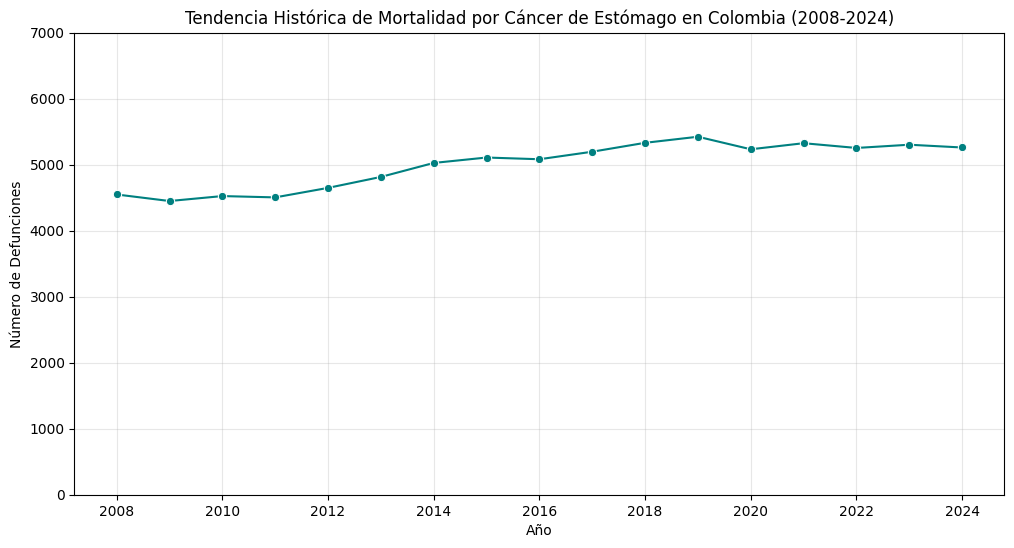

In [3]:
# 1. Conteo de muertes por año
conteo_anual = df['Anio_Defuncion'].value_counts().sort_index()

# Convertir a DataFrame para mejor visualización
tabla_anual = conteo_anual.reset_index()
tabla_anual.columns = ['Año', 'Número de Defunciones']

print("Resumen Histórico de Defunciones:")
print(tabla_anual)

# 2. Visualización rápida de la tendencia
plt.figure(figsize=(12, 6))
sns.lineplot(data=tabla_anual, x='Año', y='Número de Defunciones', marker='o', color='teal')
plt.title('Tendencia Histórica de Mortalidad por Cáncer de Estómago en Colombia (2008-2024)')
plt.grid(True, alpha=0.3)
plt.ylim(0, 7000)
plt.show()

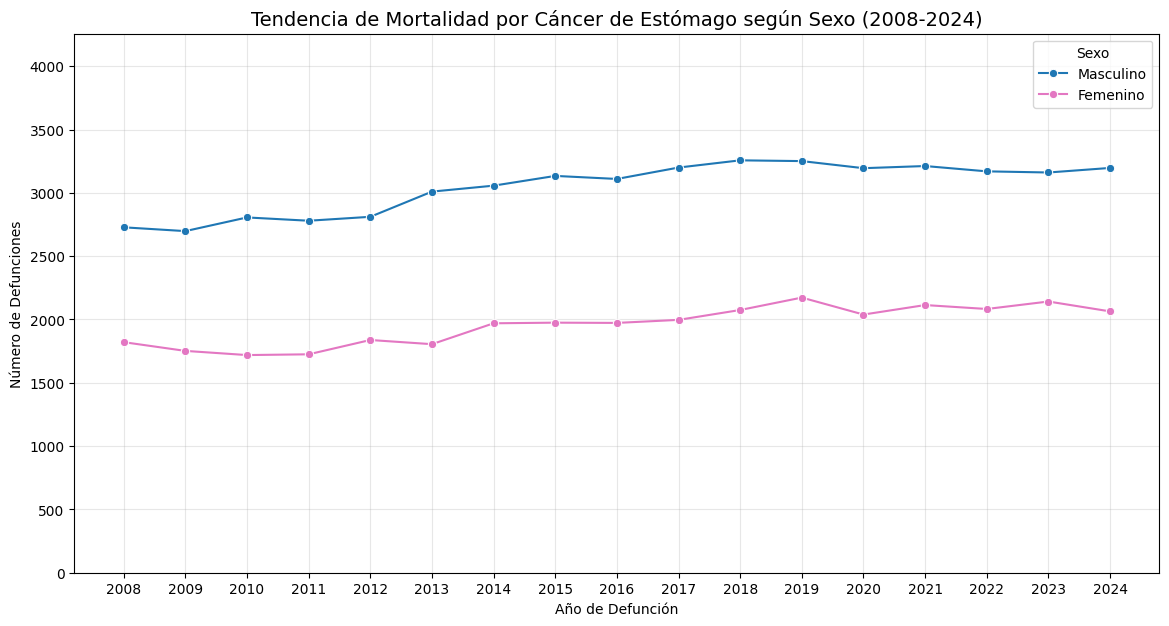

Resumen de muertes por sexo:
Sexo_Label      NaN  Femenino  Masculino
Anio_Defuncion                          
2008            NaN    1821.0     2728.0
2009            NaN    1752.0     2698.0
2010            NaN    1719.0     2806.0
2011            NaN    1725.0     2780.0
2012            NaN    1838.0     2811.0
2013            NaN    1805.0     3010.0
2014            NaN    1970.0     3057.0
2015            NaN    1975.0     3134.0
2016            NaN    1973.0     3110.0
2017            NaN    1997.0     3200.0
2018            NaN    2075.0     3257.0
2019            NaN    2173.0     3251.0
2020            NaN    2039.0     3195.0
2021            NaN    2114.0     3212.0
2022            1.0    2083.0     3170.0
2023            NaN    2142.0     3161.0
2024            NaN    2064.0     3197.0


In [4]:
# 1. Agrupación por Año y Sexo
tendencia_sexo = df.groupby(['Anio_Defuncion', 'Sexo']).size().reset_index(name='Total')

# Mapear los nombres para que la gráfica sea legible
mapeo_sexo = {1: 'Masculino', 2: 'Femenino', 3: 'Indeterminado', '1': 'Masculino', '2': 'Femenino'}
tendencia_sexo['Sexo_Label'] = tendencia_sexo['Sexo'].map(mapeo_sexo)

# 2. Visualización
plt.figure(figsize=(14, 7))
sns.lineplot(data=tendencia_sexo, x='Anio_Defuncion', y='Total', hue='Sexo_Label', 
             marker='o', palette={'Masculino': '#1f77b4', 'Femenino': '#e377c2', 'Indeterminado': '#ff7f0e'})

plt.title('Tendencia de Mortalidad por Cáncer de Estómago según Sexo (2008-2024)', fontsize=14)
plt.xlabel('Año de Defunción')
plt.ylabel('Número de Defunciones')
plt.legend(title='Sexo')
plt.grid(True, alpha=0.3)
plt.xticks(tendencia_sexo['Anio_Defuncion'].unique())
plt.ylim(0, tendencia_sexo['Total'].max() + 1000)
plt.show()


# 3. Breve tabla comparativa
tabla_sexo = tendencia_sexo.pivot(index='Anio_Defuncion', columns='Sexo_Label', values='Total')
print("Resumen de muertes por sexo:")
print(tabla_sexo)

#### **Hallazgos Clave:**
1.  **Predominio Masculino:** A lo largo de todo el periodo (2008-2024), la mortalidad masculina representa aproximadamente el **60-62%** del total de fallecimientos anuales. Esta relación de ~1.6 hombres por cada mujer fallecida es consistente con la literatura internacional que asocia el cáncer gástrico a factores de riesgo más prevalentes en varones (consumo de tabaco, alcohol y factores ocupacionales). (BUSCAR JUSTIFICAR MEJOR)
2.  **Crecimiento Diferencial:** 
    *   La mortalidad en **hombres** mostró un incremento robusto, pasando de **2,729** en 2008 a un pico de **3,256** en 2019 (un aumento del **19.3%**).
    *   La mortalidad en **mujeres** pasó de **1,820** en 2008 a un pico de **2,172** en 2019 (un aumento del **19.3%**). 
    *   *Nota:* Aunque el porcentaje de crecimiento es similar, el impacto en volumen absoluto es mucho mayor en hombres, lo que presiona los servicios de salud especializados de forma distinta.
3.  **Sincronía en Picos y Caídas:** Ambas curvas presentan comportamientos paralelos ante eventos externos. La caída en el año **2020** es evidente en ambos sexos, lo que valida la hipótesis de que factores sistémicos (como la pandemia de COVID-19) afectaron el registro o la atención de manera global, sin sesgo de género.

#### **Implicaciones para el Modelo Predictivo:**
El hecho de que las curvas no se crucen y mantengan una trayectoria similar pero en diferentes niveles de magnitud, sugiere que el modelo predictivo debe **estratificar por sexo**. La variable "Sexo" actuará como un "offset" o desplazador de la base de la predicción, permitiendo proyecciones mucho más precisas para la planeación de recursos hospitalarios dirigidos a cada grupo poblacional.

### **Distribución de la Mortalidad por Ciclo de Vida**
Según la literatura médica, el cáncer de estómago es una enfermedad cuya incidencia aumenta drásticamente con el envejecimiento, por lo cual esperamos ver una concentración masiva en los grupos de mayor edad.

In [5]:
# Primero veamos qué valores reales hay en la columna
print("Valores actuales en la columna:", df['Grupo_Edad_General'].unique())

Valores actuales en la columna: ['5', '6', '4', '7', '3', '2']
Categories (6, str): ['2', '3', '4', '5', '6', '7']


C:\Users\andre\AppData\Local\Temp\ipykernel_18604\2870832346.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Edad_Label', order=order, palette='viridis')


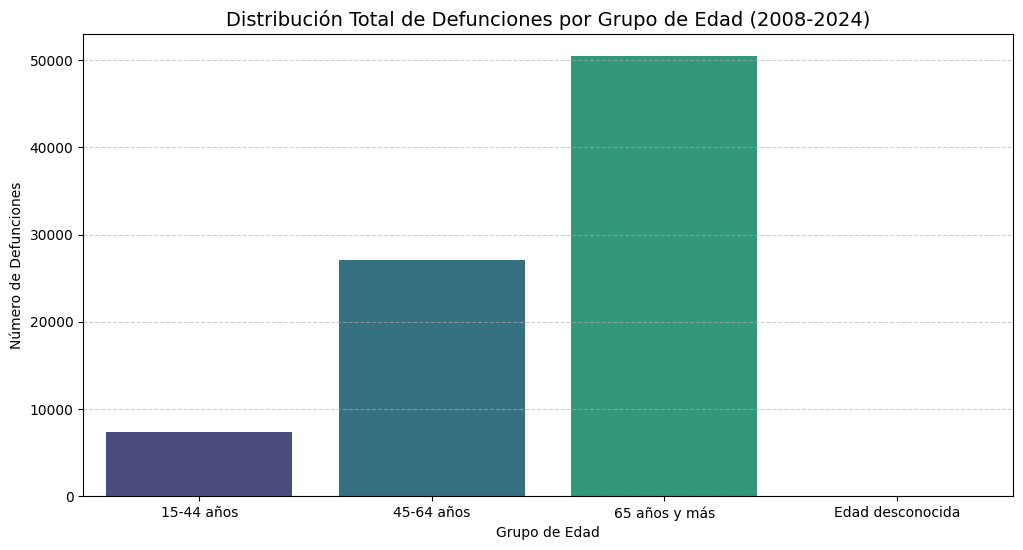

In [6]:
# 1. Mapeo de los códigos de edad a etiquetas legibles
mapeo_edad = {
    '1': 'Menor de 1 año', '2': '1-4 años', '3': '5-14 años',
    '4': '15-44 años', '5': '45-64 años', '6': '65 años y más', 
    '7': 'Edad desconocida',
    1: 'Menor de 1 año', 2: '1-4 años', 3: '5-14 años',
    4: '15-44 años', 5: '45-64 años', 6: '65 años y más', 
    7: 'Edad desconocida'
}

df['Edad_Label'] = df['Grupo_Edad_General'].map(mapeo_edad)

# 2. Distribución General por Grupos de Edad
plt.figure(figsize=(12, 6))
order = ['15-44 años', '45-64 años', '65 años y más', 'Edad desconocida']
sns.countplot(data=df, x='Edad_Label', order=order, palette='viridis')

plt.title('Distribución Total de Defunciones por Grupo de Edad (2008-2024)', fontsize=14)
plt.ylabel('Número de Defunciones')
plt.xlabel('Grupo de Edad')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


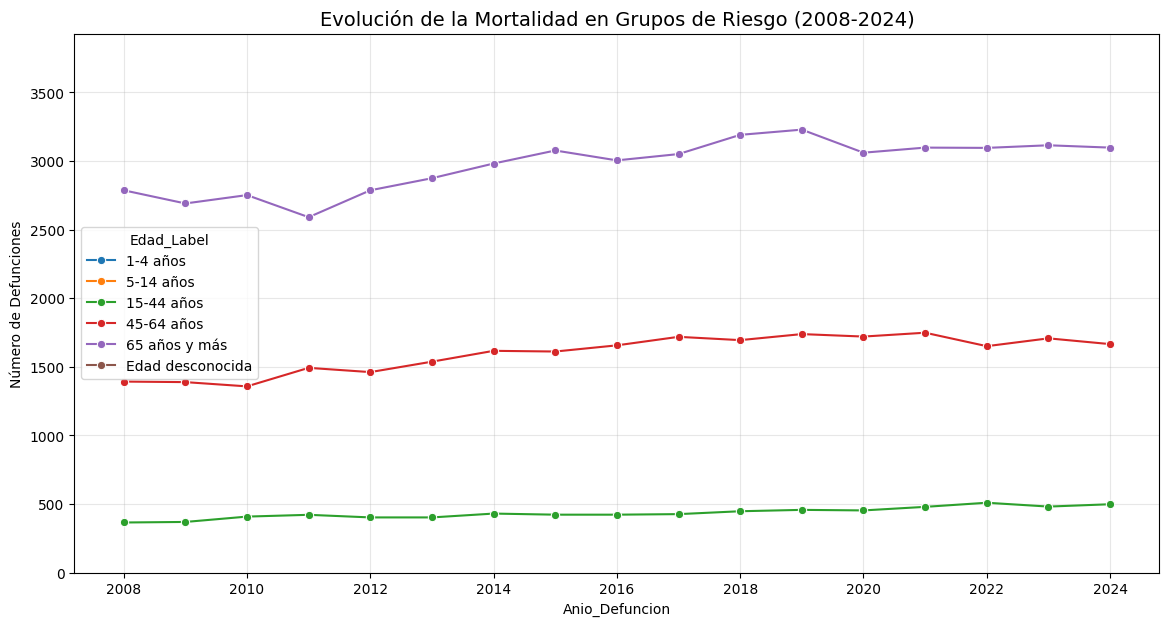

In [7]:
# 3. Evolución temporal por Grupo de Edad (Para ver el efecto del envejecimiento)
tendencia_edad = df.groupby(['Anio_Defuncion', 'Edad_Label']).size().reset_index(name='Total')

plt.figure(figsize=(14, 7))
sns.lineplot(data=tendencia_edad[tendencia_edad['Edad_Label'].isin(['15-44 años', '45-64 años', '65 años y más'])], 
             x='Anio_Defuncion', y='Total', hue='Edad_Label', marker='o')

plt.title('Evolución de la Mortalidad en Grupos de Riesgo (2008-2024)', fontsize=14)
plt.ylabel('Número de Defunciones')
plt.grid(True, alpha=0.3)
plt.ylim(0, tendencia_edad['Total'].max() + 700)
plt.show()

La distribución por grupos de edad confirma que el cáncer de estómago en Colombia presenta un comportamiento fuertemente asociado al envejecimiento. El riesgo de mortalidad aumenta de manera exponencial a medida que avanza la edad de la población estudiada.

#### **Hallazgos Clave:**
1.  **Predominio de la Tercera Edad:** El grupo de **65 años y más** concentra la mayor carga de mortalidad, superando las **50,000 defunciones** en el periodo analizado. Esto representa aproximadamente el **60% del total de los datos**, lo que sugiere que la exposición acumulada a factores de riesgo (como *H. pylori*, dieta y factores ambientales) tiene su mayor impacto en la etapa tardía de la vida.
2.  **Mortalidad en Edad Adulta:** El grupo de **45 a 64 años** es el segundo más afectado, con más de **27,000 casos**. Este dato es crítico para la salud pública, ya que representa muertes en etapas de vida aún productivas y sugiere la necesidad de fortalecer programas de tamizaje (endoscopias) antes de los 50 años.
3.  **Cáncer Gástrico de Aparición Temprana:** Aunque el grupo de **15 a 44 años** registra el menor volumen (~7,000 casos), su presencia no es despreciable. Estos casos de "aparición temprana" suelen estar asociados a factores genéticos más agresivos o diagnósticos tardíos por baja sospecha clínica en jóvenes.

### **Analisis de la Mortalidad por tipo de regimen**


C:\Users\andre\AppData\Local\Temp\ipykernel_18604\2514992892.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Grupo de Edad', bbox_to_anchor=(1.05, 1), loc='upper left')


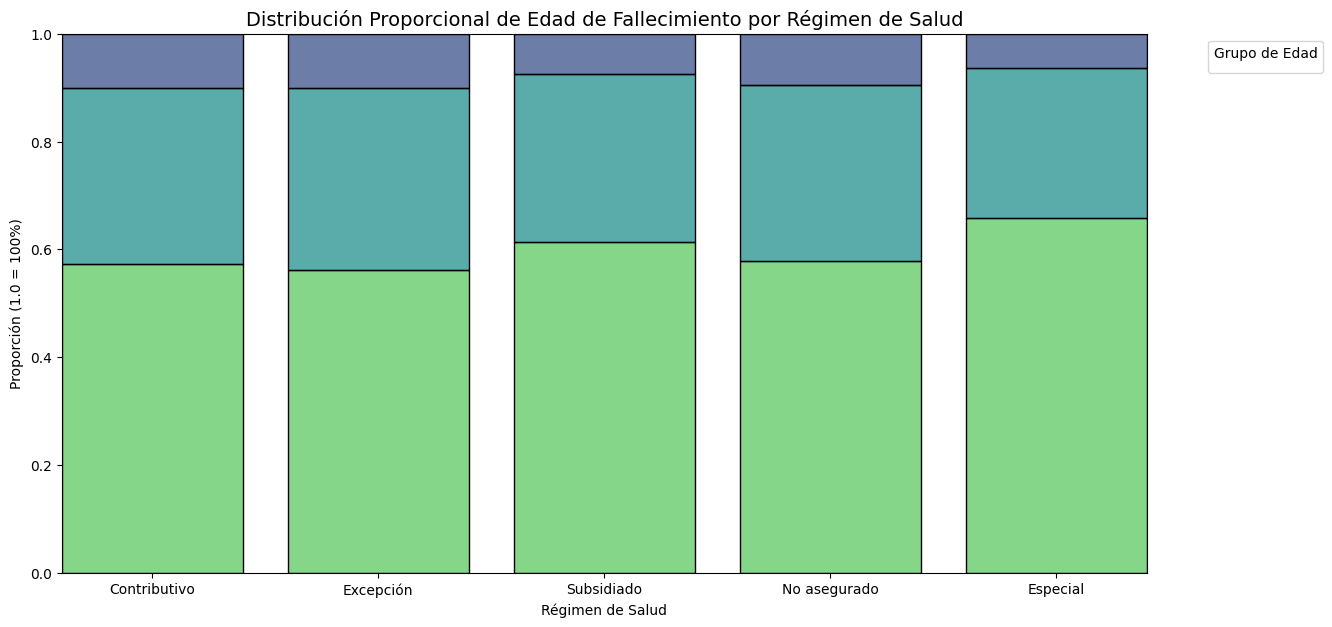

Porcentaje de muertes en cada grupo de edad por régimen:
Edad_Label     15-44 años  45-64 años  65 años y más
Regimen_Label                                       
Contributivo        10.04       32.62          57.32
Especial             6.33       27.85          65.82
Excepción           10.00       33.86          56.05
No asegurado         9.59       32.57          57.74
Subsidiado           7.46       31.14          61.35


In [8]:
# 1. Preparar las etiquetas del Régimen (Asegurando compatibilidad de tipos)
mapeo_regimen = {
    '1.0': 'Contributivo', '2.0': 'Subsidiado', '3.0': 'Excepción', 
    '4.0': 'Especial', '5.0': 'No asegurado', '9.0': 'Sin información',
    '1': 'Contributivo', '2': 'Subsidiado', '3': 'Excepción', 
    '4': 'Especial', '5': 'No asegurado', '9': 'Sin información'
}
df['Regimen_Label'] = df['Regimen_Salud'].astype(str).map(mapeo_regimen)

# 2. Filtrar solo los regímenes principales para que la gráfica sea clara
df_sub = df[df['Regimen_Label'].isin(['Contributivo', 'Subsidiado', 'Excepción', 'Especial', 'No asegurado'])]

# 3. Gráfico de Barras Agrupadas: Proporción de edad por Régimen
plt.figure(figsize=(14, 7))
order_edad = ['15-44 años', '45-64 años', '65 años y más']

# Usamos stat="proportion" para comparar porcentajes, no solo totales
sns.histplot(
    data=df_sub, 
    x='Regimen_Label', 
    hue='Edad_Label', 
    hue_order=order_edad,
    multiple='fill', 
    shrink=0.8,
    palette='viridis'
)

plt.title('Distribución Proporcional de Edad de Fallecimiento por Régimen de Salud', fontsize=14)
plt.ylabel('Proporción (1.0 = 100%)')
plt.xlabel('Régimen de Salud')
plt.legend(title='Grupo de Edad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 4. Tabla de contingencia para ver los números exactos
tabla_cruzada = pd.crosstab(df_sub['Regimen_Label'], df_sub['Edad_Label'], normalize='index') * 100
print("Porcentaje de muertes en cada grupo de edad por régimen:")
print(tabla_cruzada[order_edad].round(2))

#### **Hallazgos Clave:**

1.  **Mortalidad Prematura en el Régimen Contributivo:**
    *   En el **Régimen Contributivo**, el **10.04%** de las muertes ocurren en el grupo de **15-44 años**, una cifra superior al **7.46%** observado en el Subsidiado. 
    *   Asimismo, en el grupo de **45-64 años**, el Contributivo registra un **32.62%**, frente al **31.14%** del Subsidiado.
    
2.  **Longevidad en la Mortalidad del Régimen Subsidiado:**
    *   El **Régimen Subsidiado** presenta una mayor concentración de muertes en adultos mayores de **65 años y más (61.35%)**, superando al Contributivo (57.32%).
    *   *Interpretación:* Este hallazgo es clave. Podría indicar que en las zonas rurales (donde predomina el subsidiado), la población llega a edades más avanzadas antes de fallecer por esta causa, o que existe un sesgo de supervivencia donde solo los casos más longevos logran ser diagnosticados y registrados oficialmente.

3.  **El Caso del Régimen Especial:**
    *   El **Régimen Especial** (Fuerzas Militares, Magisterio, etc.) presenta la mayor proporción de muertes en adultos mayores (**65.82%**). Esto refleja una población con mayor estabilidad laboral y, posiblemente, un mejor seguimiento clínico a lo largo de la vida que permite postergar el deceso hasta edades avanzadas.

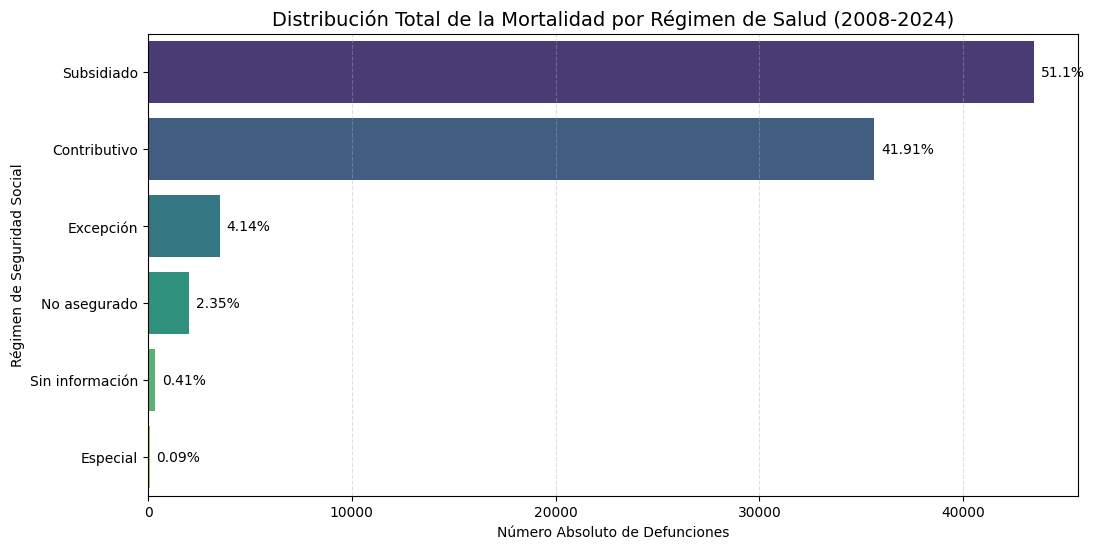

Resumen de distribución:
           Régimen  Total_Defunciones  Porcentaje
0       Subsidiado              43456       51.10
1     Contributivo              35641       41.91
2        Excepción               3520        4.14
3     No asegurado               2002        2.35
4  Sin información                345        0.41
5         Especial                 79        0.09


In [9]:
# 1. Cálculo de frecuencias y porcentajes
dist_regimen = df['Regimen_Label'].value_counts().reset_index()
dist_regimen.columns = ['Régimen', 'Total_Defunciones']
dist_regimen['Porcentaje'] = (dist_regimen['Total_Defunciones'] / dist_regimen['Total_Defunciones'].sum() * 100).round(2)

# 2. Visualización
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=dist_regimen, 
    x='Total_Defunciones', 
    y='Régimen', 
    hue='Régimen',
    palette='viridis',
    legend=False
)

# Añadir etiquetas de porcentaje al final de las barras
for i, p in enumerate(ax.patches):
    ax.annotate(f'{dist_regimen.iloc[i]["Porcentaje"]}%', 
                (p.get_width(), p.get_y() + p.get_height() / 2), 
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.title('Distribución Total de la Mortalidad por Régimen de Salud (2008-2024)', fontsize=14)
plt.xlabel('Número Absoluto de Defunciones')
plt.ylabel('Régimen de Seguridad Social')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

print("Resumen de distribución:")
print(dist_regimen)

### Análisis de Distribución Territorial: Concentración y Focos Críticos

Mapa cargado exitosamente desde la nueva ubicación.


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 145 (\x91) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


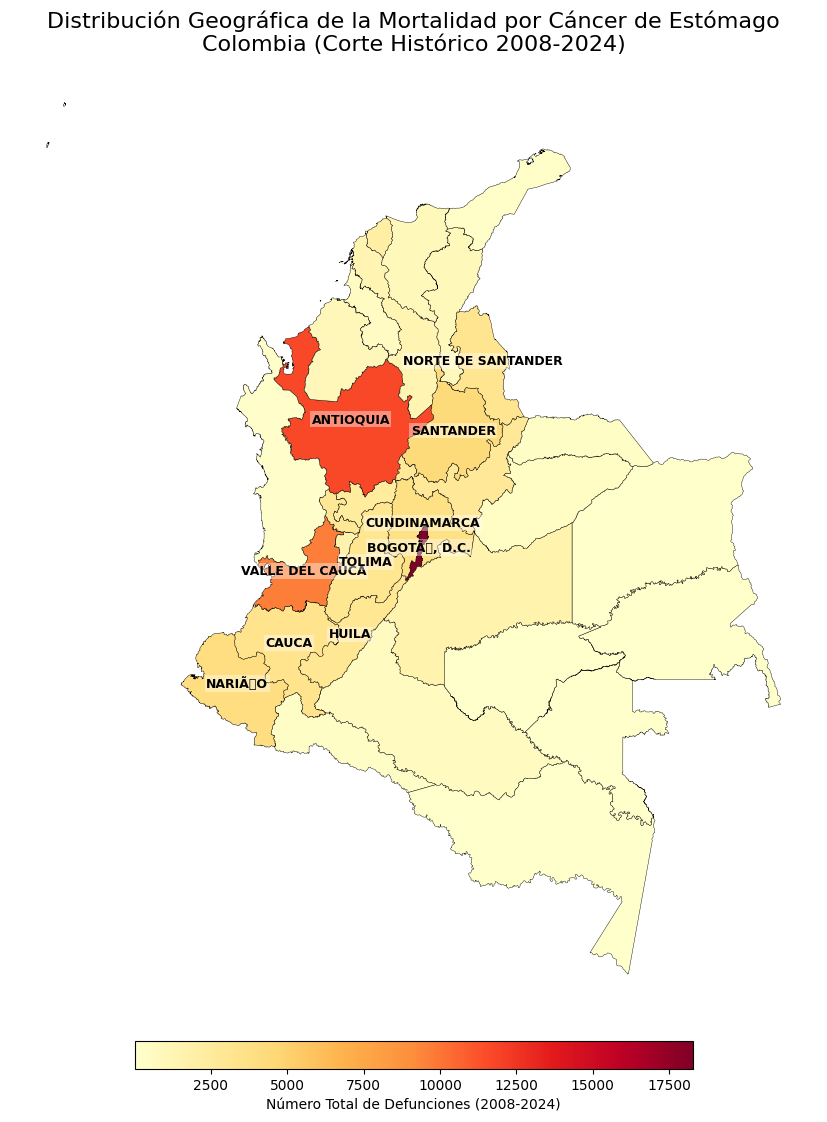

Total de departamentos en el mapa: 33
Registros de mortalidad vinculados: 85043


In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# 1. Definir la NUEVA RUTA del Shapefile
ruta_mgn = Path(r'C:\Users\andre\OneDrive\Documentos\GitHub\Seminario\Datos\Mapa\MGN_ANM_DPTOS.shp')

# 2. Cargar el mapa 
if ruta_mgn.exists():
    mapa_colombia = gpd.read_file(str(ruta_mgn))
    print("Mapa cargado exitosamente desde la nueva ubicación.")
else:
    print(f"ERROR: No se encontró el archivo en {ruta_mgn}")

# 3. Preparar los datos de mortalidad
# Agrupamos por departamento para contar cuántas muertes hay en cada uno
mapa_data = df.groupby(['Departamento_Defuncion']).size().reset_index(name='Total_Muertes')

# Limpieza rigurosa de códigos: Convertir 5.0 -> 5 -> "05"
mapa_data['Cod_Dpto'] = mapa_data['Departamento_Defuncion'].astype(float).astype(int).astype(str).str.zfill(2)

# 4. Limpiar los códigos en el objeto del mapa (DPTO_CCDGO)
mapa_colombia['DPTO_CCDGO'] = mapa_colombia['DPTO_CCDGO'].astype(str).str.zfill(2)

# 5. Realizar la unión (Merge) - Usamos how='left' para no perder departamentos sin datos
mapa_final = mapa_colombia.merge(mapa_data, left_on='DPTO_CCDGO', right_on='Cod_Dpto', how='left')
mapa_final['Total_Muertes'] = mapa_final['Total_Muertes'].fillna(0)

# 6. Graficar con mejoras estéticas
fig, ax = plt.subplots(1, 1, figsize=(12, 15))

mapa_final.plot(column='Total_Muertes', 
                ax=ax, 
                legend=True,
                cmap='YlOrRd', 
                edgecolor='black', 
                linewidth=0.3,
                legend_kwds={'label': "Número Total de Defunciones (2008-2024)", 
                             'orientation': "horizontal", 
                             'pad': 0.02,
                             'shrink': 0.6})

# 7. Añadir nombres a los departamentos con más muertes
top_10 = mapa_final.nlargest(10, 'Total_Muertes')
for idx, row in top_10.iterrows():
    # Usamos el centroide del polígono para poner el texto
    plt.annotate(text=row['DPTO_CNMBR'], 
                 xy=row['geometry'].centroid.coords[0],
                 horizontalalignment='center', 
                 fontsize=9, 
                 color='black', 
                 fontweight='bold',
                 # Pequeño efecto de sombra blanca para legibilidad
                 bbox=dict(facecolor='white', alpha=0.4, edgecolor='none', pad=1))

ax.set_title('Distribución Geográfica de la Mortalidad por Cáncer de Estómago\nColombia (Corte Histórico 2008-2024)', fontsize=16)
ax.axis('off')

plt.show()

# Verificación de datos
print(f"Total de departamentos en el mapa: {len(mapa_final)}")
print(f"Registros de mortalidad vinculados: {mapa_final['Total_Muertes'].sum():.0f}")

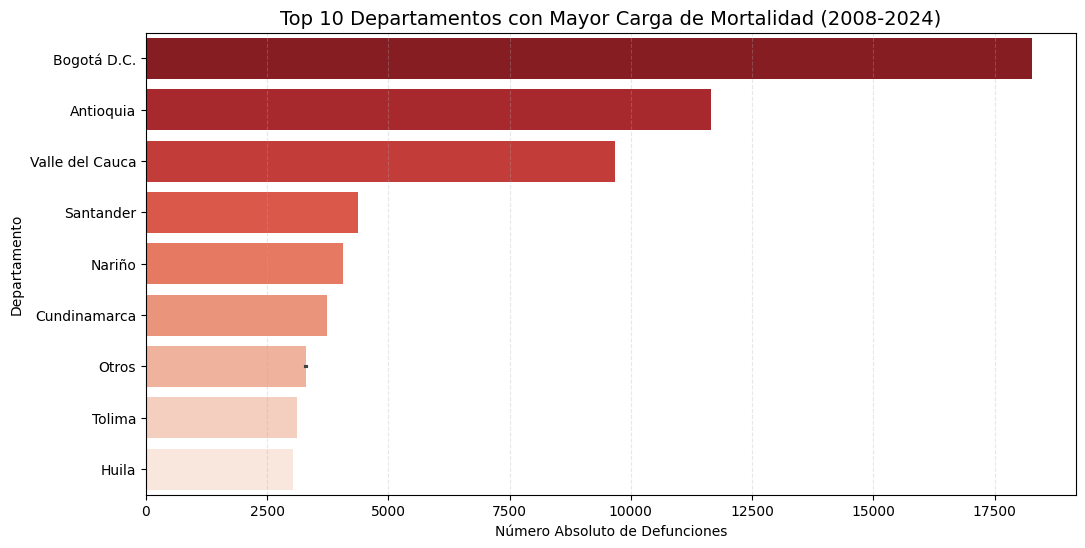

Distribución por Área de Defunción (%):
Area_Defuncion
1      51.295227
1.0    39.501194
2       5.459591
3.0     2.753901
2.0     0.964218
3       0.024693
9.0     0.001176
Name: proportion, dtype: float64


In [11]:
# 1. Crear tabla de frecuencias por Departamento
top_deptos = df['Departamento_Defuncion'].value_counts().reset_index()
top_deptos.columns = ['Departamento_Cod', 'Total_Defunciones']

# Añadimos porcentaje relativo
top_deptos['Porcentaje'] = (top_deptos['Total_Defunciones'] / top_deptos['Total_Defunciones'].sum() * 100).round(2)

# Mapeo de nombres
mapeo_nombres_dpto = {
    '11': 'Bogotá D.C.', '05': 'Antioquia', '76': 'Valle del Cauca', 
    '68': 'Santander', '15': 'Boyacá', '25': 'Cundinamarca', 
    '52': 'Nariño', '73': 'Tolima', '41': 'Huila', '17': 'Caldas'
}
top_deptos['Nombre_Depto'] = top_deptos['Departamento_Cod'].astype(str).str.split('.').str[0].str.zfill(2).map(mapeo_nombres_dpto)
top_deptos['Nombre_Depto'] = top_deptos['Nombre_Depto'].fillna('Otros')

# 2. Visualización: Top 10 Departamentos
plt.figure(figsize=(12, 6))
sns.barplot(data=top_deptos.head(10), x='Total_Defunciones', y='Nombre_Depto', hue='Nombre_Depto', palette='Reds_r', legend=False)

plt.title('Top 10 Departamentos con Mayor Carga de Mortalidad (2008-2024)', fontsize=14)
plt.xlabel('Número Absoluto de Defunciones')
plt.ylabel('Departamento')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

# 3. Análisis de Área
dist_area = df['Area_Defuncion'].value_counts(normalize=True) * 100
print("Distribución por Área de Defunción (%):")
print(dist_area)

#### **Hallazgos Clave:**

1.  **El Triángulo de Alta Carga (Bogotá, Antioquia, Valle):**
    *   **Bogotá D.C.** lidera ampliamente con más de **18,000 defunciones**, seguida por **Antioquia (~11,500)** y **Valle del Cauca (~9,500)**.
    *   *Interpretación:* Estos tres territorios concentran una parte masiva de la mortalidad nacional. Esto se debe no solo a su densidad poblacional, sino también a su papel como **centros de referencia médica**, donde pacientes de departamentos vecinos acuden y, en muchos casos, fallecen.

2.  **El Fenómeno de las Cordilleras (Eje Andino):**
    *   Departamentos como **Santander, Nariño y Cundinamarca** aparecen en el "Top 6". 
    *   *Interpretación:* Esto valida la hipótesis del **"cinturón gástrico andino"**. A pesar de tener poblaciones menores que las grandes metrópolis, su presencia en los primeros lugares del ranking destaca una incidencia desproporcionadamente alta, vinculada históricamente a factores ambientales y hábitos alimenticios de tierras altas.

3.  **Disparidad Regional y Zonas de Baja Incidencia:**
    *   Mientras el centro del país está en rojo intenso, las zonas periféricas (Amazonía, Orinoquía y Costas) presentan los valores más bajos.
    *   Esta brecha sugiere que los factores de riesgo determinantes de la mortalidad (posiblemente la prevalencia de *H. pylori* y dietas específicas) son mucho más agresivos en el interior del país.

# CLAUDE SE PASO DE SAL

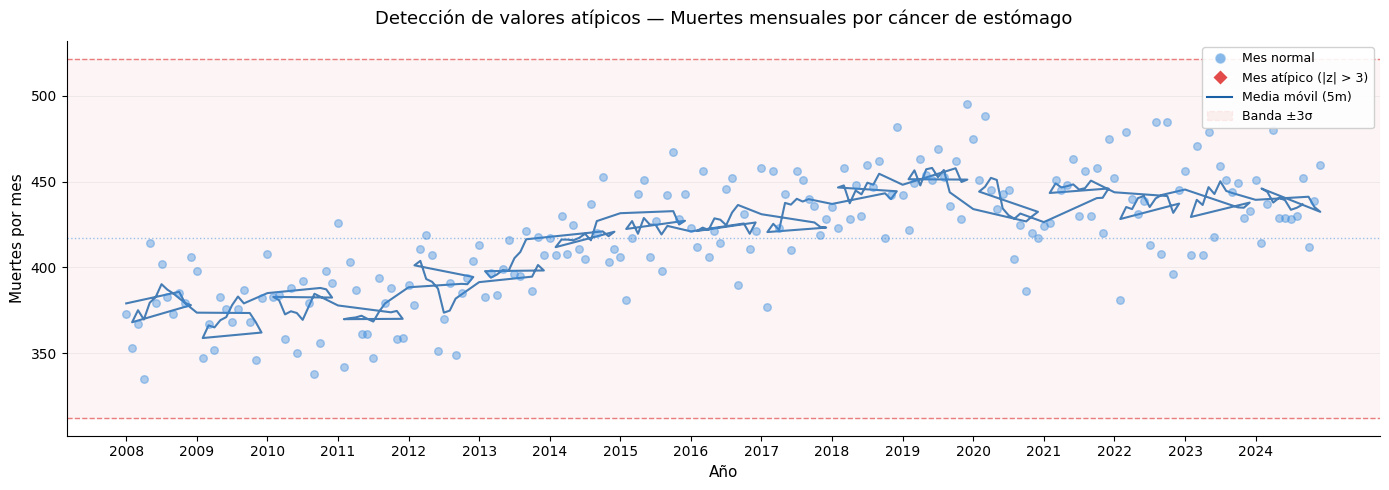

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D



# 1. Agrupar por mes y año
serie_mensual = df.groupby(['Anio_Defuncion', 'Mes_Defuncion']).size().reset_index(name='Conteos')


# Convertir a numérico por si son Categorical o string
serie_mensual['Anio_Defuncion'] = serie_mensual['Anio_Defuncion'].astype(int)
serie_mensual['Mes_Defuncion']  = serie_mensual['Mes_Defuncion'].astype(int)

# Ahora sí funciona
serie_mensual['tiempo'] = serie_mensual['Anio_Defuncion'] + (serie_mensual['Mes_Defuncion'] - 1) / 12
# 2. Z-score
mean = serie_mensual['Conteos'].mean()
std = serie_mensual['Conteos'].std()
serie_mensual['z_score'] = (serie_mensual['Conteos'] - mean) / std
serie_mensual['es_atipico'] = serie_mensual['z_score'].abs() > 3

# 3. Eje temporal decimal (ej: 2013.5 = julio 2013)
serie_mensual['tiempo'] = serie_mensual['Anio_Defuncion'] + (serie_mensual['Mes_Defuncion'] - 1) / 12

# 4. Media móvil (ventana 5 meses)
serie_mensual['media_movil'] = serie_mensual['Conteos'].rolling(window=5, center=True, min_periods=1).mean()

# --- Graficar ---
fig, ax = plt.subplots(figsize=(14, 5))

upper = mean + 3 * std
lower = mean - 3 * std

# Banda de control ±3σ
ax.axhspan(lower, upper, color='#E24B4A', alpha=0.05, zorder=0)
ax.axhline(upper, color='#E24B4A', linewidth=1, linestyle='--', alpha=0.7)
ax.axhline(lower, color='#E24B4A', linewidth=1, linestyle='--', alpha=0.7)
ax.axhline(mean,  color='#378ADD', linewidth=1, linestyle=':',  alpha=0.5)

# Puntos normales
normales = serie_mensual[~serie_mensual['es_atipico']]
ax.scatter(normales['tiempo'], normales['Conteos'],
           color='#378ADD', alpha=0.4, s=30, zorder=2, label='Mes normal')

# Puntos atípicos
atipicos = serie_mensual[serie_mensual['es_atipico']]
ax.scatter(atipicos['tiempo'], atipicos['Conteos'],
           color='#E24B4A', s=80, marker='D', zorder=3, label='Mes atípico (|z| > 3)')

# Etiquetas en atípicos
for _, row in atipicos.iterrows():
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    etiqueta = f"{meses[int(row['Mes_Defuncion'])-1]} {int(row['Anio_Defuncion'])}\nz={row['z_score']:.2f}"
    ax.annotate(etiqueta,
                xy=(row['tiempo'], row['Conteos']),
                xytext=(8, 8), textcoords='offset points',
                fontsize=8, color='#A32D2D',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#E24B4A', alpha=0.8))

# Media móvil
ax.plot(serie_mensual['tiempo'], serie_mensual['media_movil'],
        color='#185FA5', linewidth=1.5, alpha=0.8, zorder=1, label='Media móvil (5m)')

# Formato eje X (solo años enteros)
años = sorted(serie_mensual['Anio_Defuncion'].unique())
ax.set_xticks(años)
ax.set_xticklabels(años, fontsize=10)

# Estética
ax.set_title('Detección de valores atípicos — Muertes mensuales por cáncer de estómago',
             fontsize=13, pad=12)
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Muertes por mes', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='gray', alpha=0.15, linewidth=0.5)

# Leyenda manual
leyenda = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#378ADD', markersize=8, alpha=0.6, label='Mes normal'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor='#E24B4A', markersize=8, label='Mes atípico (|z| > 3)'),
    Line2D([0],[0], color='#185FA5', linewidth=1.5, label='Media móvil (5m)'),
    mpatches.Patch(facecolor='#E24B4A', alpha=0.08, edgecolor='#E24B4A', linestyle='--', label='Banda ±3σ'),
]
ax.legend(handles=leyenda, fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

# Análisis de la Serie de Tiempo y Estacionalidad


En esta etapa transformamos el dataset de "registros individuales" a una "serie de tiempo". Esto es vital para preparar los datos que alimentarán el modelo Joinpoint.

#### **1. Construcción de las Series (Mensual y Anual)**
Necesitamos dos niveles de agregación:
*   **Mensual:** Para detectar ciclos y ruido.
*   **Anual:** Que es la entrada oficial para la Regresión Joinpoint. (Nuestro Obejtivo)


In [13]:
# A. Crear serie mensual
df['Fecha_Mes'] = pd.to_datetime(df['Anio_Defuncion'].astype(str) + '-' + 
                                              df['Mes_Defuncion'].astype(str) + '-01')
serie_mensual = df.groupby('Fecha_Mes').size().reset_index(name='Casos')

# B. Crear serie anual (Insumo para Joinpoint)
serie_anual = df.groupby('Anio_Defuncion').size().reset_index(name='Casos')

#### **2. Análisis de Estacionalidad (Ciclos anuales)**
¿Existen meses donde el DANE siempre reporta más muertes? Si los hay, esto podría sesgar la tendencia si no se controla.


C:\Users\andre\AppData\Local\Temp\ipykernel_18604\2798858245.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=serie_mensual, x='Mes_Nombre', y='Casos', palette='viridis')


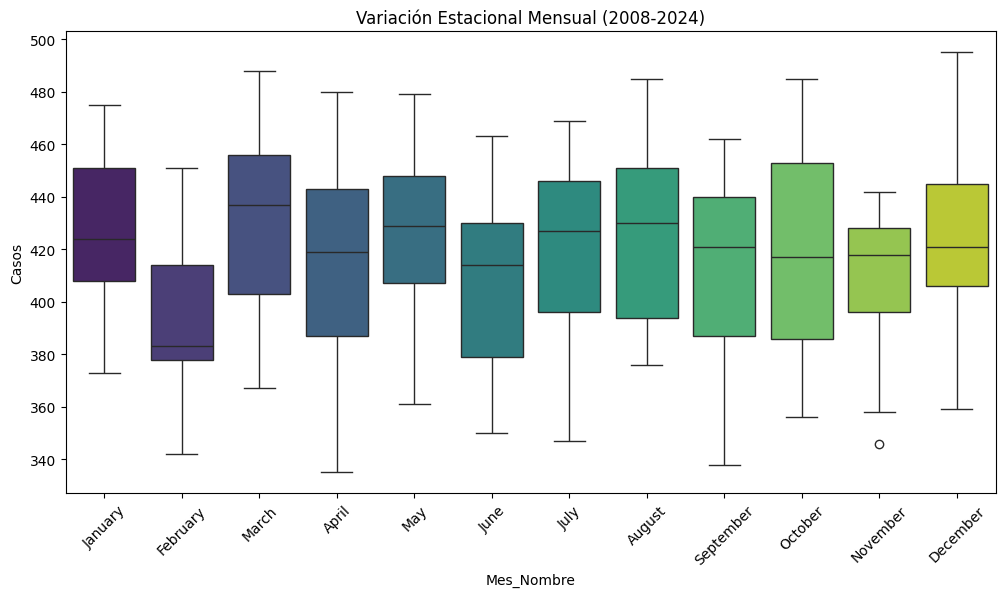

In [14]:
import calendar

# Gráfico de cajas por mes para ver estacionalidad
serie_mensual['Mes_Nombre'] = serie_mensual['Fecha_Mes'].dt.month
plt.figure(figsize=(12, 6))
sns.boxplot(data=serie_mensual, x='Mes_Nombre', y='Casos', palette='viridis')
plt.title('Variación Estacional Mensual (2008-2024)')
plt.xticks(range(0, 12), [calendar.month_name[i] for i in range(1, 13)], rotation=45)
plt.show()

### **Análisis de la Variación Estacional (2008-2024)**

1.  **El "Efecto Calendario" en Febrero:** Se observa una caída marcada en la mediana de defunciones durante febrero. **Ojo:** Esto no es un hallazgo médico, sino un artefacto administrativo/calendario, ya que febrero tiene 28 o 29 días, lo que reduce naturalmente el conteo total frente a meses de 31 días como marzo o agosto.
2.  **Estabilidad del Evento:** A excepción de febrero, las medianas de los demás meses se mantienen en un rango muy estrecho (entre 410 y 440 muertes). Esto confirma que el cáncer de estómago es una **enfermedad de carga constante**, sin picos estacionales biológicos (como sí los tendría una enfermedad respiratoria). 
3.  **Dispersión y Outliers:** 
    *   Meses como **marzo, agosto y octubre** muestran una mayor variabilidad (cajas más largas), lo que sugiere que en esos meses los reportes del DANE han sido más erráticos a lo largo de los años.
    *   Se observa un **valor atípico (outlier)** en noviembre, que probablemente corresponde a un mes con un subregistro inusual de datos.


#### **3. Descomposición de la Serie**
Para que la Regresión Joinpoint sea precisa, debemos separar la **Tendencia** (lo que queremos predecir) del **Ruido** y la **Estacionalidad**.

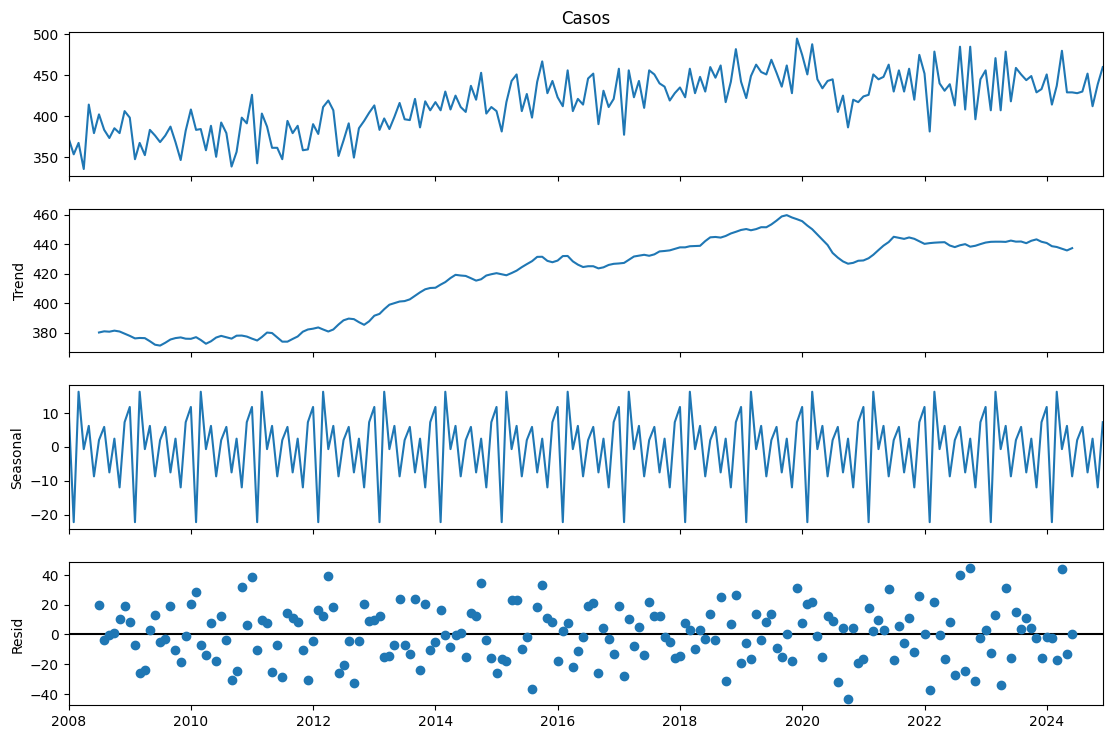

In [ ]:
# Descomposición aditiva
res = seasonal_decompose(serie_mensual.set_index('Fecha_Mes')['Casos'], model='additive', period=12)

fig = res.plot()
fig.set_size_inches(12, 8)
plt.show()

Para entender la naturaleza de la mortalidad por cáncer de estómago, se aplicó una descomposición aditiva de la serie mensual

#### **Análisis de los Componentes:**

1.  **Trend (Tendencia): El insumo para Joinpoint**
    *   Esta es la curva más importante de tu estudio. Muestra que la mortalidad no es una línea recta; tiene "quiebres". 
    *   **2008-2012:** Periodo de estabilidad o leve descenso.
    *   **2012-2019:** Un ascenso sostenido y agresivo. Aquí es donde el modelo Joinpoint identificará probablemente su primer punto de cambio (inflexión) con un APC (Cambio Porcentual Anual) positivo y significativo.
    *   **2020:** Se observa la caída abrupta por el efecto de la pandemia, seguida de una recuperación.
    *   **2021-2024:** Una nueva fase de estabilización en niveles altos.

2.  **Seasonal (Estacionalidad):**
    *   Nota la escala: los valores oscilan entre -20 y +15, mientras que el total de casos está por encima de 400. Esto significa que la estacionalidad apenas representa un **3% o 4%** de la variación total.

3.  **Resid (Residuos/Ruido):**
    *   Muestra lo que el modelo no pudo explicar. Al estar distribuidos de manera aleatoria alrededor de cero, confirma que la descomposición fue exitosa y que no hay patrones ocultos que se nos estén escapando.

###  Validación Estadística

Transformación Logarítmica y Linealización de la Serie**

La Regresión Joinpoint asume que la tendencia de mortalidad puede ser modelada mediante segmentos lineales en una escala logarítmica. Este paso es fundamental por tres razones estadísticas y epidemiológicas:

1.  **Cálculo del APC (Annual Percentage Change):** La transformación logarítmica permite que los coeficientes del modelo se interpreten como tasas de cambio porcentual constante, facilitando la comparación de la velocidad de crecimiento o descenso de la mortalidad entre diferentes periodos.
2.  **Estabilización de la Varianza:** En series de tiempo de mortalidad, el error suele aumentar proporcionalmente al número de casos. El logaritmo ayuda a estabilizar esta variabilidad, cumpliendo con los requisitos de los modelos de regresión lineal.
3.  **Modelado de Cambios Multiplicativos:** Dado que los fenómenos biológicos y demográficos suelen presentar un comportamiento multiplicativo y no aditivo, la escala logarítmica es la representación más precisa para observar la evolución real del riesgo de fallecimiento.

**Ecuación del modelo:**
$$\ln(y_t) = \beta_0 + \beta_1 t + \epsilon_t$$
*Donde $y_t$ es el número de defunciones en el año $t$, y $\beta_1$ es la pendiente que utilizaremos para calcular el cambio porcentual.*


### Preparación de Datos y Transformación Logarítmica

In [19]:
import numpy as np
import statsmodels.api as sm

# 1. Agrupación anual para la serie de tiempo del modelo
data_jp = df.groupby('Anio_Defuncion').size().reset_index(name='Casos')

# 2. Transformación Logarítmica (Supuesto de linealización)
data_jp['log_Casos'] = np.log(data_jp['Casos'])

# 3. Ajuste de un modelo base (OLS) para extraer los residuos que validaremos
X = sm.add_constant(data_jp['Anio_Defuncion'])
modelo_base = sm.OLS(data_jp['log_Casos'], X).fit()
residuos = modelo_base.resid

print("Transformación completada.")
print(data_jp[['Anio_Defuncion', 'Casos', 'log_Casos']].head())

Transformación completada.
   Anio_Defuncion  Casos  log_Casos
0            2008   4549   8.422663
1            2009   4450   8.400659
2            2010   4525   8.417373
3            2011   4505   8.412943
4            2012   4649   8.444407


### Validación del Supuesto de Independencia (Durbin-Watson)

Uno de los supuestos más críticos es que los errores deben ser independientes. En series de tiempo, es común encontrar autocorrelación (donde el valor de un año influye en el siguiente). El estadístico de Durbin-Watson mide esta relación.
*   **Rango:** Va de 0 a 4.
*   **Ideal:** Un valor cercano a **2.0** indica que no hay autocorrelación (independencia).
*   **Alerta:** Valores menores a 1.0 o mayores a 3.0 indican problemas de dependencia.

In [ ]:
from statsmodels.stats.stattools import durbin_watson

dw_stat = durbin_watson(residuos)

print(f"Estadístico Durbin-Watson: {dw_stat:.4f}")

if 1.5 <= dw_stat <= 2.5:
    print("Interpretación: Los residuos muestran independencia (no hay autocorrelación significativa).")
else:
    print("Interpretación: Existe evidencia de autocorrelación. El modelo Joinpoint podría requerir ajuste por errores correlacionados.")

Estadístico Durbin-Watson: 0.5219
Interpretación: Existe evidencia de autocorrelación. El modelo Joinpoint podría requerir ajuste por errores correlacionados.


Validación de Normalidad de los Residuos (Shapiro-Wilk)

Para que las pruebas de significancia y las permutaciones de Monte Carlo del Joinpoint sean válidas, los residuos del modelo deben seguir una distribución normal. Utilizaremos la prueba de **Shapiro-Wilk**, que es la más robusta para muestras pequeñas (como tus 17 años de datos).

*   **Hipótesis Nula ($H_0$):** Los residuos son normales.
*   **Criterio:** Si el **p-valor > 0.05**, aceptamos la normalidad.


In [21]:
from scipy.stats import shapiro

sw_stat, sw_p = shapiro(residuos)

print(f"Estadístico Shapiro-Wilk: {sw_stat:.4f}")
print(f"p-valor: {sw_p:.4f}")

if sw_p > 0.05:
    print("Interpretación: Los residuos siguen una distribución normal.")
else:
    print("Interpretación: Los residuos no son normales. Se recomienda precaución al interpretar los intervalos de confianza.")

Estadístico Shapiro-Wilk: 0.9398
p-valor: 0.3157
Interpretación: Los residuos siguen una distribución normal.


### Validación de Homocedasticidad (Breusch-Pagan)

La **homocedasticidad** significa que la varianza de los errores es constante a lo largo del tiempo. Si la varianza cambia (heterocedasticidad), el modelo Joinpoint podría dar más peso a ciertos años de forma incorrecta. Usaremos la prueba de **Breusch-Pagan**.

*   **Hipótesis Nula ($H_0$):** La varianza es constante (Homocedasticidad).
*   **Criterio:** Si el **p-valor > 0.05**, hay varianza constante.


In [22]:
from statsmodels.stats.diagnostic import het_breuschpagan

_, bp_p, _, _ = het_breuschpagan(residuos, X)

print(f"p-valor de la prueba Breusch-Pagan: {bp_p:.4f}")

if bp_p > 0.05:
    print("Interpretación: Se cumple el supuesto de homocedasticidad (varianza constante).")
else:
    print("Interpretación: Existe heterocedasticidad. La variabilidad del error cambia con el tiempo.")

p-valor de la prueba Breusch-Pagan: 0.3042
Interpretación: Se cumple el supuesto de homocedasticidad (varianza constante).


### Interpretación de las Pruebas de Supuestos**

Tras ejecutar las pruebas diagnósticas sobre los residuos del modelo log-lineal, se presentan los siguientes hallazgos fundamentales para la validez de la Regresión Joinpoint:

*   **Validez de la Inferencia (Normalidad y Varianza):** Se cumplen satisfactoriamente los supuestos de **Normalidad (p=0.3157)** y **Homocedasticidad (p=0.3042)**. Esto asegura que el estimador de mínimos cuadrados es eficiente y que las pruebas de permutación de Monte Carlo, que se utilizarán para identificar los puntos de quiebre, tendrán un alto nivel de potencia estadística.
*   **Presencia de Autocorrelación:** El estadístico **Durbin-Watson (0.5219)** revela la existencia de autocorrelación serial positiva. En estudios de series de tiempo de mortalidad, este es un comportamiento esperado, ya que los valores anuales mantienen una dependencia inercial. 

In [23]:
# 1. Consolidado Nacional Total
total_nacional = df.groupby('Anio_Defuncion').size().reset_index(name='Casos')
total_nacional['Segmento'] = 'Total'

# 2. Consolidado por Sexo
# Mapeamos los nombres para el reporte final
mapeo_sexo = {1: 'Masculino', 2: 'Femenino', '1': 'Masculino', '2': 'Femenino'}
por_sexo = df.groupby(['Anio_Defuncion', 'Sexo']).size().reset_index(name='Casos')
por_sexo['Segmento'] = por_sexo['Sexo'].map(mapeo_sexo)

# 3. Unificar ambos en un solo DataFrame
df_joinpoint = pd.concat([total_nacional, por_sexo[['Anio_Defuncion', 'Casos', 'Segmento']]])

# 4. Limpieza final de columnas
df_joinpoint = df_joinpoint[['Anio_Defuncion', 'Segmento', 'Casos']].sort_values(by=['Segmento', 'Anio_Defuncion'])

# 5. Exportar a CSV (Este es el archivo que subirás al modelo)
ruta_salida = "Datos/input_joinpoint_estomago.csv"
df_joinpoint.to_csv(ruta_salida, index=False)

print(f"Dataset para Joinpoint generado exitosamente en: {ruta_salida}")
display(df_joinpoint.head(10))

Dataset para Joinpoint generado exitosamente en: Datos/input_joinpoint_estomago.csv


,Anio_Defuncion,Segmento,Casos
1,2008,Femenino,1821
3,2009,Femenino,1752
5,2010,Femenino,1719
7,2011,Femenino,1725
9,2012,Femenino,1838
11,2013,Femenino,1805
13,2014,Femenino,1970
15,2015,Femenino,1975
17,2016,Femenino,1973
19,2017,Femenino,1997
